# Hump Algebra

We consider finite signed mixtures of Gaussian humps:
$$
f(x)=\sum_i a_i\,\exp\!\left(-\frac{(x-\mu_i)^2}{2\sigma_i^2}\right),\qquad
g(x)=\sum_j b_j\,\exp\!\left(-\frac{(x-\nu_j)^2}{2\tau_j^2}\right).
$$
This family is stable under addition and product, which motivates the algebraic viewpoint.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
x = np.linspace(-4, 4, 900)

def mix(x, mus, sigs, amps):
    out = np.zeros_like(x)
    for m,s,a in zip(mus,sigs,amps):
        out += a*np.exp(-0.5*((x-m)/s)**2)
    return out


## Product of two signed two-Gaussian mixtures


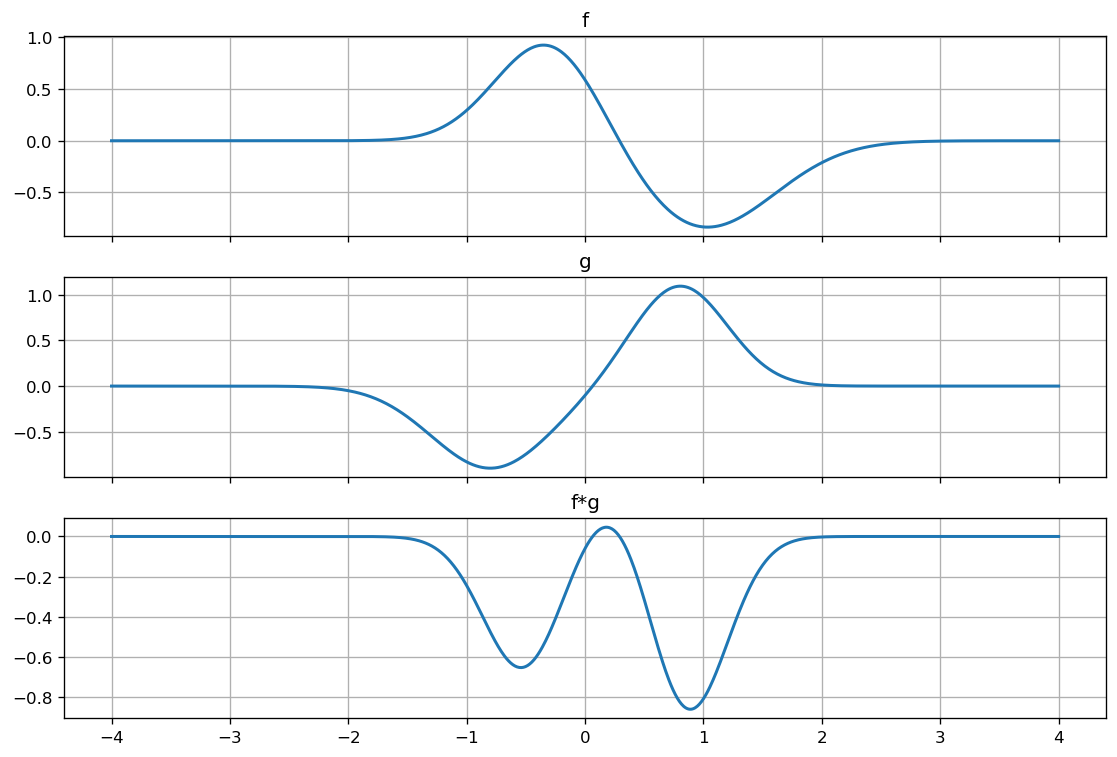

In [2]:
def build(theta=0.0):
    mus_f = np.array([-1.2 + 0.9*np.cos(theta), 1.0 + 0.7*np.sin(theta)])
    mus_g = np.array([-0.8 + 0.8*np.sin(theta), 1.4 - 0.6*np.cos(theta)])
    f = mix(x, mus_f, [0.45, 0.6], [1.0, -0.85])
    g = mix(x, mus_g, [0.5, 0.4], [-0.9, 1.1])
    return f, g, f*g

f0, g0, h0 = build(0.0)
fig, axes = plt.subplots(3, 1, figsize=(9.2, 6.2), sharex=True, constrained_layout=True)
axes[0].plot(x, f0, lw=1.8); axes[0].set_title('f')
axes[1].plot(x, g0, lw=1.8); axes[1].set_title('g')
axes[2].plot(x, h0, lw=1.8); axes[2].set_title('f*g')
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()


## Interactive motion of means


## Bibliographical Resources

- Y. Meyer, *Wavelets and Operators*, Cambridge University Press, 1992.
- Y. Meyer, *Oscillating Patterns in Image Processing and Nonlinear Evolution Equations*, AMS, 2001.
